In [1]:
## Load my files ##
import sys
sys.path.append('..')
from utils import get_sequence

## Load standard files ##
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler
from torch import from_numpy as tnsr
from scipy.stats import bernoulli
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist as dist
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
n_community = 2
n_members = 3

tokens = []

for ii in range(n_community*n_members+1):
    tokens.append(
        chr(ord('A')+ii)
    )

In [3]:
class network_wake(nn.Module):
    def __init__(self, input_size, hidden_wake_size, hidden_sleep_size, num_layers=2, num_layers_sleep=2):
        super(network_wake, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_wake_size, num_layers, nonlinearity='relu', batch_first=True)
        self.wake_fc = nn.Linear(hidden_wake_size, len(tokens))

    def forward(self, x, hw=None):
        if hw == None:
            out, hw = self.rnn(x)
        else:
            out, hw = self.rnn(x, hw)

        out = self.wake_fc(out)
        
        return out, hw

In [4]:
class network_sleep(nn.Module):
    def __init__(self, input_size, hidden_sleep_size, num_layers=1):
        super(network_sleep, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_sleep_size, num_layers, nonlinearity='relu', batch_first=True)
        self.sleep_fc = nn.Linear(hidden_sleep_size, len(tokens))

    def forward(self, x, hs=None):
        if hs == None:
            out, hs = self.rnn(x)
        else:
            out, hs = self.rnn(x, hs)

        out = self.sleep_fc(out)
        
        return out, hs

In [5]:
class compressor(nn.Module):
    def __init__(self, input_size, hidden_compressor_size, num_layers=1):
        super(compressor, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_compressor_size, num_layers, nonlinearity='relu', batch_first=True)
        self.compressor_fc = nn.Linear(hidden_compressor_size, 2)

    def forward(self, x, hc=None):
        if hc == None:
            out, hc = self.rnn(x)
        else:
            out, hc = self.rnn(x, hc)

        out = self.compressor_fc(out)
        
        return out, hc

In [6]:
def compute_geodesic(hidden1, hidden2):

    total_layers = len(hidden1)
    w = 0

    for ii in range(total_layers):
        w_ = np.array(dist( hidden1[ii], hidden2[ii], 'cosine'))
        w += w_
           
    return w[0][0]/total_layers

In [7]:
class Dataset_converter(Dataset):
    def __init__(self, data, working_memory=1, short_term_memory=8):
        
        one_hot_encoded = np.zeros((len(data), len(tokens)), dtype=float)
        for ii, token in enumerate(data):
            one_hot_encoded[ii,ord(token)-65] = 1
        
        self.X = np.zeros((((len(data)-working_memory-short_term_memory)), short_term_memory, len(tokens)*working_memory))
        self.y = np.zeros((((len(data)-working_memory-short_term_memory)), len(tokens)))

        for ii in range(self.X.shape[0]):
            for jj in range(self.X.shape[1]):
                for kk in range(working_memory):
                    self.X[ii,jj,kk*len(tokens):(kk+1)*len(tokens)] = \
                    one_hot_encoded[ii+jj+kk,:]
                    
            self.y[ii] = \
                one_hot_encoded[ii+jj+kk+1,:]

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [8]:
class Dataset_converter_compressor(Dataset):
    def __init__(self, data, mask):
        total_sample = len(data)
        self.X = np.zeros((total_sample-2, len(tokens)))
        self.y = np.zeros((total_sample-2, 2))
        for ii in range(total_sample-2):
            token = data[ii]
            self.X[ii, ord(token)-65] = 1 
            self.y[ii,mask[ii]] = 1
            

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [ ]:
### initial training ###
total_samples = 40000
working_memory = 1
short_term_memory = 1
hidden_wake_size = 50
hidden_compressor_size = 5
hidden_sleep_size = 50
num_layers_wake = 1
num_layers_sleep = 1
output_sleep = len(tokens)
input_size = 5*len(tokens)*working_memory
additional_input = torch.zeros((1,1,4*len(tokens)))

lr = 4e-4
test_acc = []

data = get_sequence(total_samples, n_community, n_members) #
data_set = Dataset_converter(data, working_memory, short_term_memory)
train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

network1 = network_wake(input_size, hidden_wake_size, hidden_sleep_size, num_layers_wake, num_layers_sleep)

optimizer = torch.optim.SGD(network1.parameters(), lr=lr, momentum=0.95)
criterion = torch.nn.CrossEntropyLoss()

total = 0
correct = np.zeros(1000,dtype=float)
for X, y in train_loader:
    # X = torch.cat((additional_input, X), dim=2)
    optimizer.zero_grad()

    if total == 0:
        predicted_y, hidden = network1(X)
    else:
        predicted_y, hidden = network1(X, hw=mem)
        
    loss = criterion(predicted_y[0], y)
    loss.backward(retain_graph=True)
    optimizer.step()

    with torch.no_grad():
        mem=hidden.clone()
        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=2)

        total += 1
        if true_y == estimated_y:
                correct[total%1000] = 1
        else:
            correct[total%1000] = 0

        test_acc.append(
            np.sum(correct)/total if total<1000 else np.sum(correct)/1000
        )
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')

Iter : 1001, loss: 1.3681, accuracy: 0.3200
Iter : 2001, loss: 1.1075, accuracy: 0.5810
Iter : 3001, loss: 0.4741, accuracy: 0.6990
Iter : 4001, loss: 0.4123, accuracy: 0.7400
Iter : 5001, loss: 0.3323, accuracy: 0.7510
Iter : 6001, loss: 0.3560, accuracy: 0.7440
Iter : 7001, loss: 0.0821, accuracy: 0.7430
Iter : 8001, loss: 0.1223, accuracy: 0.7630
Iter : 9001, loss: 0.1029, accuracy: 0.7550
Iter : 10001, loss: 0.0435, accuracy: 0.7510
Iter : 11001, loss: 0.0744, accuracy: 0.7390
Iter : 12001, loss: 0.0384, accuracy: 0.7420
Iter : 13001, loss: 0.0213, accuracy: 0.7690
Iter : 14001, loss: 0.0122, accuracy: 0.7400
Iter : 15001, loss: 0.0254, accuracy: 0.7600
Iter : 16001, loss: 0.0134, accuracy: 0.7580
Iter : 17001, loss: 0.0110, accuracy: 0.7690
Iter : 18001, loss: 0.0478, accuracy: 0.7820
Iter : 19001, loss: 0.0299, accuracy: 0.7740
Iter : 20001, loss: 0.0517, accuracy: 0.7700
Iter : 21001, loss: 0.1208, accuracy: 0.7800
Iter : 22001, loss: 0.0149, accuracy: 0.8070
Iter : 23001, loss:

In [61]:
compressor_sample = 10000

data_compressor = get_sequence(compressor_sample, n_community, n_members) #pd.read_csv("Seq_500000.txt")['seq'][0][total_samples:total_samples+compressor_sample]#
data_set_compressor = Dataset_converter(data_compressor, working_memory, short_term_memory)
compressor_loader = DataLoader(data_set_compressor, batch_size=1, shuffle=False) 

ii = 0
dis = [0]
# community = ''

with torch.no_grad():
    for X, _ in compressor_loader:
        X = torch.cat((additional_input, X), dim=2)
        if ii==0:
            id, hw = network1(X)
            id_current = hw
            # community = tokens[torch.argmax(X[0])]
        else:
            id, hw = network1(X, hw=hw)
            id_current = hw
            if ii>=1:
                dis.append(compute_geodesic(prev_id, id_current))
                # print(dis)
                # if dis[-1] >0.407:
                #     # print(dis, tokens[torch.argmax(X[0])])
                #     community += tokens[torch.argmax(X[0])]
                    
            
        prev_id = id_current
        ii += 1

In [62]:
dis_array = np.array(dis)
threshold = np.quantile(dis_array, .6)

mask = ((dis_array>threshold)*1)

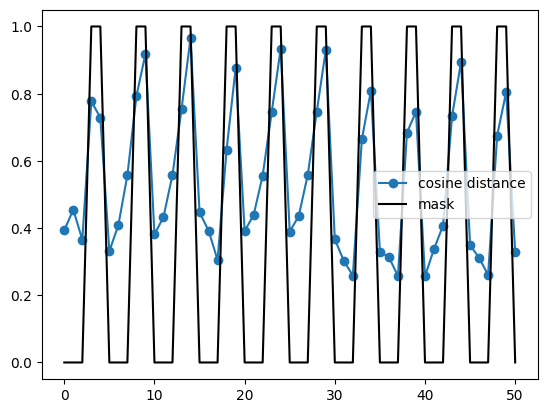

In [63]:
span = 51
plt.plot(dis[1:span+1], '-o', label='cosine distance')
plt.plot(mask[1:span+1], c='k', label = 'mask')
plt.legend()

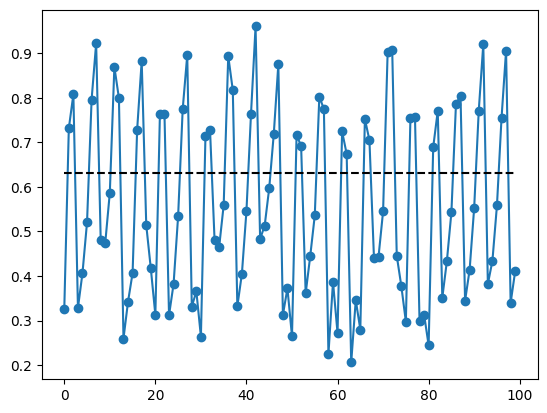

In [64]:
span = 100
plt.plot(dis[-span:], '-o')
plt.plot(np.arange(span), [threshold]*span, '--', c='k')

In [65]:
mask[-100:]

array([0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0])

In [66]:
data_set = Dataset_converter_compressor(data_compressor, mask)
compressor_loader = DataLoader(data_set, batch_size=1, shuffle=False) 
compression = []

compressor_model = compressor(len(tokens), hidden_compressor_size)
optimizer = torch.optim.SGD(compressor_model.parameters(), lr=4e-3, momentum=0.95)
criterion = torch.nn.CrossEntropyLoss()

total = 0
correct = np.zeros(1000, dtype=float)
for X, y in compressor_loader:
    optimizer.zero_grad()

    if total == 0:
        predicted_y, hidden = compressor_model(X)
    else:
        predicted_y, hidden = compressor_model(X, hc=mem)
        
    loss = criterion(predicted_y, y)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        mem = hidden.clone()

        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=1)

        if estimated_y[0]:
            compression.append((true_y[0],estimated_y[0],tokens[X.argmax(axis=1)]))
            
        total += 1
        if true_y == estimated_y:
            correct[total%1000] = 1
        else:
            correct[total%1000] = 0

        test_acc.append(
            np.sum(correct)/total if total<1000 else np.sum(correct)/1000
        )
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')



Iter : 1001, loss: 0.0015, accuracy: 0.9490
Iter : 2001, loss: 0.0045, accuracy: 1.0000
Iter : 3001, loss: 0.0000, accuracy: 1.0000
Iter : 4001, loss: 0.0002, accuracy: 1.0000
Iter : 5001, loss: 0.0002, accuracy: 1.0000
Iter : 6001, loss: 0.0000, accuracy: 1.0000
Iter : 7001, loss: 0.0001, accuracy: 1.0000
Iter : 8001, loss: 0.0004, accuracy: 1.0000
Iter : 9001, loss: 0.0005, accuracy: 1.0000


In [67]:
compressed_seq = ''
data = get_sequence(3000, n_community, n_members, train=False)#pd.read_csv("Seq_500000.txt")['seq'][0][total_samples:total_samples+compressor_sample]#
data_test = Dataset_converter_compressor(data, mask)
test_loader = DataLoader(data_test, batch_size=1, shuffle=False) 

total = 0
correct = np.zeros(1000, dtype=float)
for X, y in test_loader:      

    with torch.no_grad():
        if total == 0:
            predicted_y, hidden = compressor_model(X)
        else:
            predicted_y, hidden = compressor_model(X, hc=hidden)


        # if total<8:
        #     print(X)
        # print(y, predicted_y)
        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=1)

        if estimated_y[0]:
            compressed_seq += tokens[X.argmax(axis=1)]
            
        total += 1

In [68]:
compressed_seq

'GDGDGCGDGEGFGDGFGFGEGCGCGFGCGCGAGCGAGDGBGEGFGBGAGFGEGDGEGCGEGCGFGBGFGFGCGFGEGCGCGFGCGDGEGEGDGEGAGEGBGFGDGDGEGAGFGBGBGFGDGAGEGBGFGAGAGAGCGCGEGEGBGBGAGDGDGAGFGCGAGEGAGEGFGFGEGDGDGBGDGDGCGBGDGCGAGDGEGAGFGAGBGDGAGBGAGDGEGAGFGAGAGBGBGBGEGAGFGCGFGEGDGDGDGCGFGEGFGFGCGFGDGCGCGFGCGCGCGBGEGDGBGAGEGBGEGDGDGEGBGAGAGEGBGEGEGDGCGDGAGCGFGAGDGFGCGCGDGBGFGBGEGAGDGBGDGCGCGBGEGCGFGBGFGAGAGBGAGBGDGAGBGFGBGBGCGDGBGBGEGAGDGCGBGFGFGBGBGCGDGFGAGAGCGBGCGFGAGFGBGCGCGDGEGEGAGBGEGFGDGEGAGCGBGDGEGAGFGCGBGEGAGEGFGFGFGBGAGCGFGEGEGBGEGDGEGDGAGCGFGEGCGAGBGEGEGBGFGEGDGEGFGAGCGCGFGCGEGCGEGEGCGAGCGFGBGBGEGEGFGDGAGDGAGBGCGBGEGFGFGCGEGAGBGEGFGEGDGDGEGCGBGDGDGEGDGEGDGFGDGEGEGCGAGBGAGFGEGFGBGDGEGFGEGFGEGFGAGBGAGBGEGDGCGDGAGBGFGCGDGAGFGAGBGBGAGEGFGDGBGDGCGEGCGAGAGBGFGDGFGCGEGCGAGDGEGFGAGDGEGCGFGCGDGDGBGAGEGEGCGEGFGFGDGDGEGBGBGEGAGEGCGAGFGEGDGFGDGCGDGFGFGCGAGFGFGBGFGEGDGCGAGBGEGAGCGAGBGBGCGEGFGFGCGBGDGDGEGAGDGBGDGBGFGFGDGBGFGBGBGEGAGFGAGBGFGAGCGAGBGCGBGBGCGCGDGAGEGDGCGFGFGEGAGAGDGDGDGDGAGEGAGDGAGBGAGBGEGEGFGDGFGAGEGBGDGAGEGAG

In [69]:
sleep_samples = 40000
compressed_seq = ''
data_sleep = get_sequence(sleep_samples, n_community, n_members)# pd.read_csv("Seq_500000.txt")['seq'][0][total_samples+compressor_sample:total_samples+compressor_sample+sleep_samples]#
data_set_sleep = Dataset_converter(data_sleep, working_memory, short_term_memory)

sleep_loader = DataLoader(data_set_sleep, batch_size=1, shuffle=False)
network2 = network_sleep(len(tokens), hidden_sleep_size, num_layers_sleep)

optimizer = torch.optim.SGD(network2.parameters(), lr=lr, momentum=0.95)
criterion = torch.nn.CrossEntropyLoss()

total = 0
total_ = 0
sleep_mem = None
correct = np.zeros(1000,dtype=float)
for X, y in sleep_loader:

    with torch.no_grad():
        if total == 0:
            y_ = X.clone()
            predicted_y, hidden = compressor_model(X[0])
        else:
            predicted_y, hidden = compressor_model(X[0], hc=hidden)

        selection = predicted_y.argmax(axis=1)

        if selection:
            sleep = True
            compressed_seq += data_sleep[total]
            X_ = y_.clone()
            y_ = X.clone()
            # print(X_,y_)
        else:
            sleep = False

        total += 1
    ####################################################################
    if sleep:
        optimizer.zero_grad()
        if total_ == 0:
            predicted_y, hidden_s = network2(X_)
        else:
            predicted_y, hidden_s = network2(X_, hs=mem)
            
        loss = criterion(predicted_y[0], y_[0])
        loss.backward(retain_graph=True)
        optimizer.step()
        

        with torch.no_grad():
            mem=hidden_s.clone()
            
            true_y = y_[0].argmax(axis=1)
            estimated_y = predicted_y.argmax(axis=2)

            total_ += 1
            if true_y == estimated_y:
                correct[total_%1000] = 1
            else:
                correct[total_%1000] = 0

            test_acc.append(
                np.sum(correct)/total_ if total_<1000 else np.sum(correct)/1000
            )
            if total_%1000 == 0:
                print(f'Iter : {total_+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')

Iter : 1001, loss: 1.4053, accuracy: 0.5320
Iter : 2001, loss: 1.5863, accuracy: 0.6270
Iter : 3001, loss: 1.4683, accuracy: 0.6360
Iter : 4001, loss: 1.2788, accuracy: 0.6210
Iter : 5001, loss: 1.5749, accuracy: 0.6200
Iter : 6001, loss: 1.2755, accuracy: 0.6330
Iter : 7001, loss: 1.6538, accuracy: 0.6420
Iter : 8001, loss: 1.4330, accuracy: 0.6110
Iter : 9001, loss: 2.0293, accuracy: 0.6390
Iter : 10001, loss: 1.5522, accuracy: 0.6330
Iter : 11001, loss: 1.3123, accuracy: 0.6250
Iter : 12001, loss: 1.6072, accuracy: 0.6340
Iter : 13001, loss: 1.3745, accuracy: 0.6190
Iter : 14001, loss: 1.4665, accuracy: 0.6230
Iter : 15001, loss: 1.6542, accuracy: 0.6260


In [70]:
compressed_seq[-100:]

'GEGDGEGAGBGAGBGAGEGEGEGEGAGEGEGAGDGBGDGBGBGDGDGEGEGDGBGAGDGDGDGDGBGDGEGEGEGEGBGAGAGDGDGDGDGEGAGEGEGB'

In [71]:
wake_samples = 50000
compressed_seq = ''
data_wake = get_sequence(wake_samples, n_community, n_members)#pd.read_csv("Seq_500000.txt")['seq'][0][total_samples+compressor_sample:]#
data_set_wake = Dataset_converter(data_wake, working_memory, short_term_memory)

wake_loader = DataLoader(data_set_wake, batch_size=1, shuffle=False)

optimizer = torch.optim.SGD(network1.parameters(), lr=lr, momentum=0.95)
criterion = torch.nn.CrossEntropyLoss()
additional_input = torch.zeros((1,1,4*len(tokens)))

total = 0
total_ = 0
sleep_mem = None
correct = np.zeros(1000,dtype=float)
for X, y in wake_loader:

    with torch.no_grad():
        if total == 0:
            predicted_y, hidden = compressor_model(X[0])
        else:
            predicted_y, hidden = compressor_model(X[0], hc=hidden)

        selection = predicted_y.argmax(axis=1)

        if selection:
            compressed_seq += data_wake[total]

            for ii in range(3):
                additional_input[0,0,ii*7:(ii+1)*7] = additional_input[0,0,(ii+1)*7:(ii+2)*7]
            
            additional_input[0,0,-7:] = X

            if total_ == 0:
                predicted_y_, hidden_s = network2(X)
            else:
                predicted_y_, hidden_s = network2(X, hidden_s)
            
            total_ += 1
    ####################################################################
    X = torch.cat((additional_input, X), dim=2)
    
    optimizer.zero_grad()

    if total == 0:
        predicted_y, hidden_wake = network1(X)
    else:
        predicted_y, hidden_wake = network1(X, hw=mem)
        
    loss = criterion(predicted_y[0], y)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        total += 1
        mem=hidden_wake.clone()
        true_y = y.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=2)

        if true_y == estimated_y:
            # print(true_y, estimated_y)
            correct[total%1000] = 1
            # print(total, correct)
            # break
        else:
            correct[total%1000] = 0

        test_acc.append(
            np.sum(correct)/total if total<1000 else np.sum(correct)/1000
        )
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, accuracy: {test_acc[-1]:.4f}')
            # break 
        

Iter : 1001, loss: 1.3219, accuracy: 0.7530
Iter : 2001, loss: 1.4858, accuracy: 0.7500
Iter : 3001, loss: 1.1288, accuracy: 0.7530
Iter : 4001, loss: 1.4543, accuracy: 0.7490
Iter : 5001, loss: 1.5572, accuracy: 0.7610
Iter : 6001, loss: 1.5113, accuracy: 0.7520
Iter : 7001, loss: 1.0055, accuracy: 0.7550
Iter : 8001, loss: 1.5386, accuracy: 0.7590
Iter : 9001, loss: 1.3117, accuracy: 0.7440
Iter : 10001, loss: 1.4353, accuracy: 0.7570
Iter : 11001, loss: 1.3346, accuracy: 0.7460
Iter : 12001, loss: 1.1875, accuracy: 0.7450
Iter : 13001, loss: 1.2282, accuracy: 0.7530
Iter : 14001, loss: 1.4178, accuracy: 0.7570
Iter : 15001, loss: 1.3522, accuracy: 0.7390
Iter : 16001, loss: 1.7945, accuracy: 0.7380
Iter : 17001, loss: 1.1097, accuracy: 0.7600
Iter : 18001, loss: 1.6047, accuracy: 0.7590
Iter : 19001, loss: 1.4524, accuracy: 0.7320
Iter : 20001, loss: 1.4139, accuracy: 0.7450
Iter : 21001, loss: 1.9923, accuracy: 0.7570
Iter : 22001, loss: 1.4855, accuracy: 0.7620
Iter : 23001, loss:

In [72]:
compressed_seq[-100:]

'GDGEGDGBGEGEGAGBGEGEGDGBGBGEGBGEGDGDGDGBGAGBGEGAGEGEGEGAGBGEGDGEGDGDGEGAGAGBGEGDGAGDGBGAGEGAGDGBGDGB'

In [39]:
X

tensor([[[0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
          0.]]])

In [287]:
predicted_y_

tensor([[[-1.6646, -1.6087, -0.2201, -2.2594, -2.2511, -0.3330,  8.0937]]])

In [14]:
X

tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
          0.]]])